# Sample Weights

## Overview

This notebook demonstrates the public functions in `sample_weights` using triple-barrier events built from dollar bars.

- The notebook counts concurrent events and measures average uniqueness.
- It computes return-attribution weights and applies time decay.
- It compares standard sampling with sequential bootstrap on the same event structure.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.Series.iteritems = pd.Series.items
np.random.seed(7)

In [2]:
from src.data_preprocessing.financial_data_labeling import get_daily_volatility, get_events, get_vertical_barriers
from src.data_preprocessing.financial_data_structures import get_cusum_events, get_dollar_bars
from src.data_preprocessing.sample_weights import (
    apply_time_decay,
    build_indicator_matrix,
    compute_average_uniqueness,
    compute_average_uniqueness_weights,
    compute_return_attribution_weights,
    count_concurrent_events,
    generate_random_t1,
    run_monte_carlo_trial,
    sequential_bootstrap,
)


## Load raw Alpaca trades and build events

This section rebuilds a labeled event set so the weighting functions can analyze realistic overlap on the same AAPL sample used throughout the preprocessing notebooks.

- The notebook starts from the shared raw Alpaca trade file and converts it into dollar bars.
- The dollar-bar threshold follows `target_bars_per_day = 24`, matching the current convention in the surrounding notebooks.
- Triple-barrier events create the overlapping horizons that the weighting functions are designed to measure.


In [3]:
data_path = Path("data/raw/alpaca/stock_aapl_trades_20260101T000000Z_20260131T000000Z.parquet")
alpaca_path = next(
    (path / data_path for path in [Path.cwd(), *Path.cwd().parents] if (path / data_path).exists()),
    data_path,
)

trades = pd.read_parquet(alpaca_path).sort_values("timestamp").reset_index(drop=True)[["timestamp", "symbol", "price", "size"]].copy()
notional = trades["price"].astype(float) * trades["size"].astype(float)
target_bars_per_day = 24
trading_days = trades["timestamp"].dt.normalize().nunique()
target_num_bars = max(1, trading_days * target_bars_per_day)
dollar_threshold = float(notional.sum() / target_num_bars)
dollar_bars = get_dollar_bars(trades, threshold=dollar_threshold).ohlcv
dollar_close = dollar_bars["close"].astype(float)

daily_volatility = get_daily_volatility(dollar_close, span0=50)
cusum_threshold = float(dollar_close.diff().abs().median() * 2)
t_events = pd.DatetimeIndex(get_cusum_events(dollar_close, threshold=cusum_threshold))
t1 = get_vertical_barriers(t_events, dollar_close, numBars=10)
targets = daily_volatility.reindex(t_events)
side = dollar_close.pct_change(5).reindex(t_events).apply(lambda value: 1.0 if value >= 0 else -1.0)

eligible_events = targets.dropna().index.intersection(side.dropna().index).intersection(t1.index)
events = get_events(
    close=dollar_close,
    tEvents=eligible_events,
    ptSl=[1.0, 1.0],
    trgt=targets,
    minRet=float(targets.loc[eligible_events].quantile(0.25)),
    numThreads=1,
    t1=t1,
    side=side,
)

print(f"source: {alpaca_path}")
print(f"trading_days: {trading_days}")
print(f"target_bars_per_day: {target_bars_per_day}")
print(f"num_dollar_bars: {len(dollar_close):,}")
print(f"num_events: {len(events):,}")
events.head()

source: /Users/kwonjunhyuk9/Documents/financial-machine-learning/data/raw/alpaca/stock_aapl_trades_20260101T000000Z_20260131T000000Z.parquet
trading_days: 20
target_bars_per_day: 24
num_dollar_bars: 479
num_events: 111


,t1,trgt,side
2026-01-08 15:02:12.885445+00:00,2026-01-08 16:51:17.894626+00:00,0.006969,-1.0
2026-01-09 14:30:25.284783+00:00,2026-01-09 14:53:16.620733+00:00,0.007767,1.0
2026-01-09 14:40:40.647607+00:00,2026-01-09 18:01:14.328404+00:00,0.008532,1.0
2026-01-09 14:53:16.620733+00:00,2026-01-09 17:29:14.661978+00:00,0.008670,-1.0
2026-01-09 15:23:03.111729+00:00,2026-01-09 19:55:46.217912+00:00,0.009644,-1.0


### Interpretation

This weighting setup now uses the same 24-bars-per-day dollar-bar convention as the neighboring preprocessing notebooks.
- On this run the raw AAPL sample spans `20` trading days and becomes `479` dollar bars, which is the same event-time resolution used in the current labeling and fractional-differencing notebooks.
- Those 479 bars produce `111` labeled events after the volatility, CUSUM, side, and vertical-barrier filters, so the weighting functions are analyzing a much richer overlap structure than the older 14-event version.
- Every concurrency count, uniqueness score, and bootstrap sample below should therefore be read as properties of this 111-event table, not as abstract statistics detached from the event construction step.


## Count Concurrent Events

This section measures how many labeled events are active on each bar.

- `count_concurrent_events` expands each event horizon across the close index.
- The resulting overlap series is the direct input to the uniqueness and weighting helpers below.
- Bars with higher concurrency contribute less unique information to any single event.

In [4]:
num_concurrent_events = count_concurrent_events(
    closeIdx=dollar_close.index,
    t1=events["t1"],
    molecule=events.index,
)

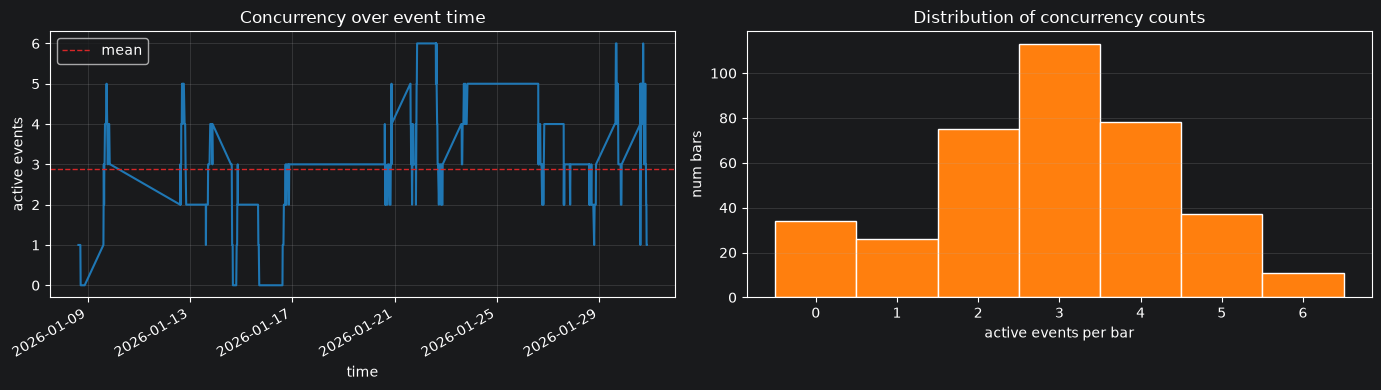

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

num_concurrent_events.plot(ax=axes[0], color="tab:blue", lw=1.5)
axes[0].axhline(num_concurrent_events.mean(), color="tab:red", ls="--", lw=1, label="mean")
axes[0].set_title("Concurrency over event time")
axes[0].set_xlabel("time")
axes[0].set_ylabel("active events")
axes[0].legend()
axes[0].grid(alpha=0.25)

bins = np.arange(num_concurrent_events.min(), num_concurrent_events.max() + 2) - 0.5
axes[1].hist(num_concurrent_events, bins=bins, color="tab:orange", edgecolor="white")
axes[1].set_title("Distribution of concurrency counts")
axes[1].set_xlabel("active events per bar")
axes[1].set_ylabel("num bars")
axes[1].set_xticks(sorted(num_concurrent_events.unique()))
axes[1].grid(axis="y", alpha=0.25)

fig.tight_layout()

### Interpretation

The concurrency plots show how crowded the labeled event timeline is.
- The left line chart tracks the number of active events at each bar. Spikes mean many event horizons overlap at the same time, so each event active during those bars receives a smaller share of unique information; flat low sections mean the events are mostly isolated.
- The right histogram summarizes the same information by count rather than by time. If most bars sit at `1`, the sample is mostly unique; if many bars sit at higher counts, overlap is a recurring feature rather than a one-off spike.

## Compute Uniqueness And Weights

This section applies the weighting helpers that operate on event horizons and returns.

- `compute_average_uniqueness_weights` averages inverse concurrency over each event horizon.
- `compute_sample_weights` attributes log returns while discounting overlapping events.
- `apply_time_decay` tilts the final weights toward newer observations without discarding the older ones entirely.


In [6]:
average_uniqueness_weights = compute_average_uniqueness_weights(
    t1=events["t1"],
    numCoEvents=num_concurrent_events,
    molecule=events.index,
)
sample_weights = compute_return_attribution_weights(
    t1=events["t1"],
    numCoEvents=num_concurrent_events,
    close=dollar_close,
    molecule=events.index,
)
time_decay_weights = apply_time_decay(sample_weights, clfLastW=0.5)

pd.concat(
    {
        "avg_uniqueness_weight": average_uniqueness_weights,
        "sample_weight": sample_weights,
        "time_decay_weight": time_decay_weights,
    },
    axis=1,
).head()

0.5 1.7897575714550422


,avg_uniqueness_weight,sample_weight,time_decay_weight
2026-01-08 15:02:12.885445+00:00,1.000000,0.004391,0.507859
2026-01-09 14:30:25.284783+00:00,0.611111,0.001895,0.511251
2026-01-09 14:40:40.647607+00:00,0.313636,0.002128,0.515060
2026-01-09 14:53:16.620733+00:00,0.300000,0.000933,0.516730
2026-01-09 15:23:03.111729+00:00,0.268182,0.003209,0.522473


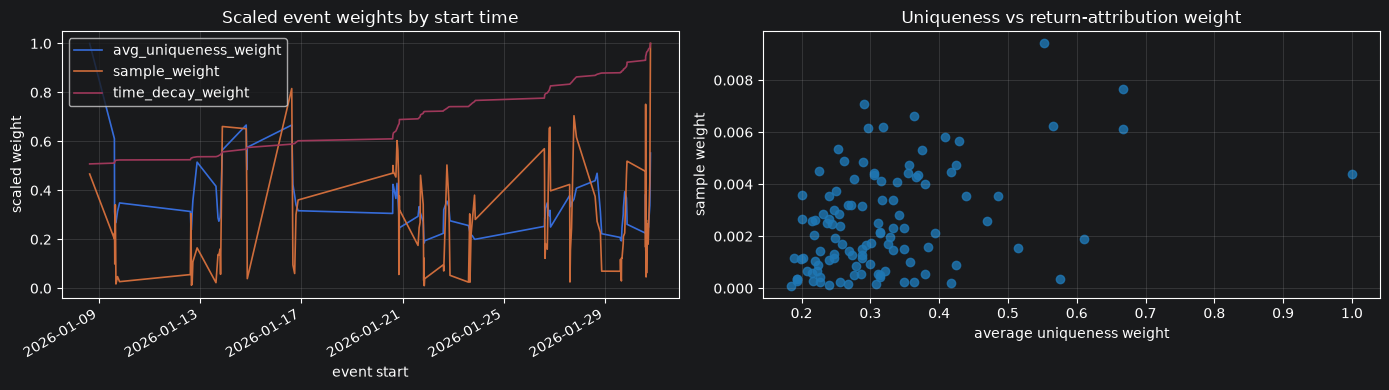

In [7]:
weights_df = pd.DataFrame(
    {
        "avg_uniqueness_weight": average_uniqueness_weights,
        "sample_weight": sample_weights,
        "time_decay_weight": time_decay_weights,
    }
)
scaled_weights = weights_df.div(weights_df.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

scaled_weights.plot(ax=axes[0], lw=1.2)
axes[0].set_title("Scaled event weights by start time")
axes[0].set_xlabel("event start")
axes[0].set_ylabel("scaled weight")
axes[0].grid(alpha=0.25)

axes[1].scatter(
    average_uniqueness_weights,
    sample_weights,
    color="tab:blue",
    alpha=0.8,
)
axes[1].set_title("Uniqueness vs return-attribution weight")
axes[1].set_xlabel("average uniqueness weight")
axes[1].set_ylabel("sample weight")
axes[1].grid(alpha=0.25)
fig.tight_layout()

### Interpretation

These plots compare the event-weight series and the direct relationship between uniqueness and return attribution.
- The left chart puts the three weight series on the same scaled range so their timing patterns are comparable. Peaks mark events that receive relatively high importance under that weighting rule; troughs mark events that are discounted because they overlap heavily, have little attributed return, or are older after time decay.
- The right scatter plot compares average uniqueness weight against return-attribution weight event by event. Points farther right are less overlapped events; points higher up contributed more return after concurrency adjustment.
- Time decay is intentionally left out of the scatter plot because it answers a different question: recency. Keeping the scatter to two variables makes it easier to see whether less-overlapped events also receive larger return-attribution weights.

## Indicator Matrix And Sequential Bootstrap

This section converts event horizons into an indicator matrix and samples event indices with sequential bootstrap.

- `build_indicator_matrix` maps each event to the bars where it is active.
- `compute_average_uniqueness` summarizes the per-event uniqueness implied by that matrix.
- `sequential_bootstrap` prefers samples that add new information instead of repeatedly selecting highly overlapping events.

In [8]:
indicator_matrix = build_indicator_matrix(dollar_close.index, events["t1"])
average_uniqueness = compute_average_uniqueness(indicator_matrix)
bootstrap_indices = sequential_bootstrap(indicator_matrix, sLength=min(10, indicator_matrix.shape[1]))

print(f"indicator_matrix_shape: {indicator_matrix.shape}")
print(f"mean_average_uniqueness: {average_uniqueness.mean():.6f}")
bootstrap_indices

indicator_matrix_shape: (479, 111)
mean_average_uniqueness: 0.319045


[np.int64(8),
 np.int64(86),
 np.int64(48),
 np.int64(79),
 np.int64(108),
 np.int64(58),
 np.int64(53),
 np.int64(7),
 np.int64(28),
 np.int64(55)]

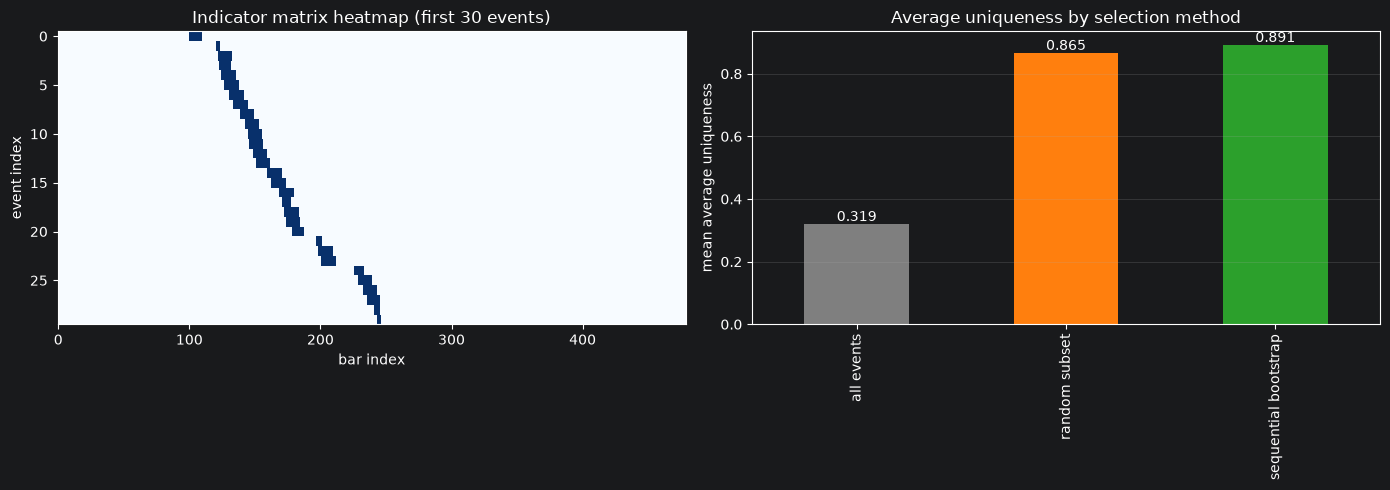

In [9]:
subset_width = min(30, indicator_matrix.shape[1])
random_indices = np.random.choice(indicator_matrix.columns, size=len(bootstrap_indices), replace=False)
selection_uniqueness = pd.Series(
    {
        "all events": average_uniqueness.mean(),
        "random subset": compute_average_uniqueness(indicator_matrix[random_indices]).mean(),
        "sequential bootstrap": compute_average_uniqueness(indicator_matrix[bootstrap_indices]).mean(),
    }
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(indicator_matrix.iloc[:, :subset_width].T, aspect="auto", cmap="Blues", interpolation="nearest")
axes[0].set_title(f"Indicator matrix heatmap (first {subset_width} events)")
axes[0].set_xlabel("bar index")
axes[0].set_ylabel("event index")

selection_uniqueness.plot(kind="bar", ax=axes[1], color=["tab:gray", "tab:orange", "tab:green"])
axes[1].set_title("Average uniqueness by selection method")
axes[1].set_xlabel("")
axes[1].set_ylabel("mean average uniqueness")
axes[1].grid(axis="y", alpha=0.25)
for patch, value in zip(axes[1].patches, selection_uniqueness):
    axes[1].text(patch.get_x() + patch.get_width() / 2, value, f"{value:.3f}", ha="center", va="bottom")

fig.tight_layout()

### Interpretation

The indicator matrix makes the overlap structure explicit and shows why bootstrap selection can matter.
- The left heatmap can be read like an event attendance chart: each row is one event, the x-axis is the dollar-bar timeline, and blue cells mark the bars where that event is active. Vertical stacks of blue cells mean several events are alive on the same bars, so those events share information rather than contributing fully independent samples.
- The right bar chart compares the average uniqueness of all events, a same-size random subset, and the sequential-bootstrap subset. A taller sequential-bootstrap bar means the selected events overlap less, on average, than the random alternative.
- In this run the full matrix has shape `(479, 111)` and mean average uniqueness around `0.319`, so the event table is meaningfully crowded; the bootstrap result should be read as a column selection from this matrix, not as resampling bars directly.

## Monte Carlo Trial

This section uses the simulation helpers to compare standard sampling and sequential bootstrap under random event horizons.

- `generate_random_t1` creates synthetic overlapping event horizons.
- `run_monte_carlo_trial` reports uniqueness from one standard sample and one sequential-bootstrap sample.
- Repeating the trial many times makes it easier to judge whether the bootstrap advantage is stable or just noise.


In [10]:
random_t1 = generate_random_t1(numObs=10, numBars=50, maxH=5)
monte_carlo = pd.DataFrame(
    [run_monte_carlo_trial(numObs=25, numBars=250, maxH=10) for _ in range(50)]
)

print("synthetic_horizons")
display(random_t1.head())
monte_carlo.agg(["mean", "std"])

synthetic_horizons


9     13
12    14
15    17
17    19
21    22
dtype: int64

,stdU,seqU
mean,0.563894,0.641060
std,0.068618,0.049091


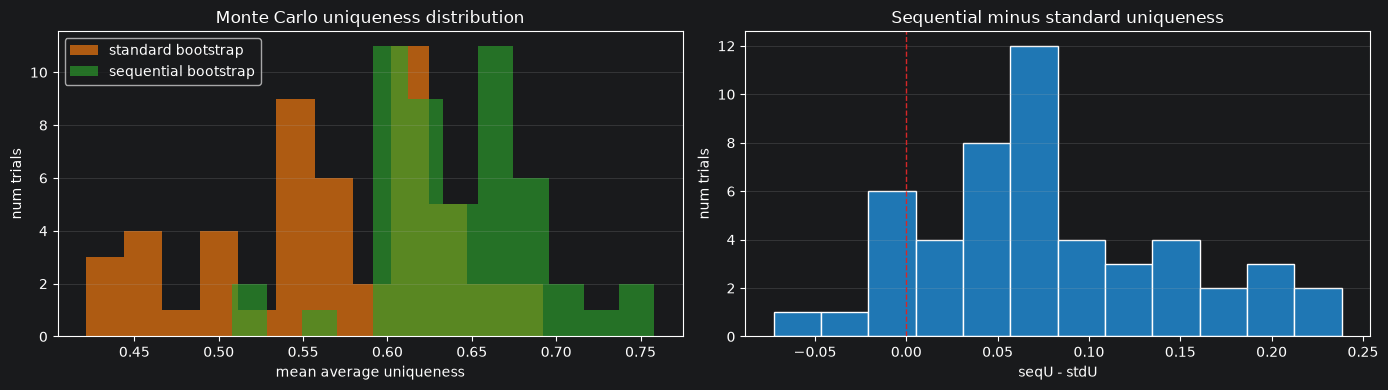

In [11]:
monte_carlo_delta = monte_carlo["seqU"] - monte_carlo["stdU"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(monte_carlo["stdU"], bins=12, alpha=0.65, label="standard bootstrap", color="tab:orange")
axes[0].hist(monte_carlo["seqU"], bins=12, alpha=0.65, label="sequential bootstrap", color="tab:green")
axes[0].set_title("Monte Carlo uniqueness distribution")
axes[0].set_xlabel("mean average uniqueness")
axes[0].set_ylabel("num trials")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

axes[1].hist(monte_carlo_delta, bins=12, color="tab:blue", edgecolor="white")
axes[1].axvline(0, color="tab:red", ls="--", lw=1)
axes[1].set_title("Sequential minus standard uniqueness")
axes[1].set_xlabel("seqU - stdU")
axes[1].set_ylabel("num trials")
axes[1].grid(axis="y", alpha=0.25)

fig.tight_layout()

### Interpretation

The Monte Carlo experiment checks whether the bootstrap advantage survives outside the specific AAPL event table used above.
- The left histogram shows the uniqueness values produced by each method across repeated trials. If the green sequential-bootstrap distribution sits to the right of the orange standard-bootstrap distribution, sequential bootstrap is usually producing less-overlapping samples.
- The right histogram removes the two separate distributions and plots the trial-by-trial difference, `seqU - stdU`. Bars to the right of the red zero line are trials where sequential bootstrap won; bars near zero mean little practical difference.
- Across 50 simulated trials, sequential bootstrap averages higher uniqueness than the standard sampler here, so the visual takeaway is not just that both methods vary, but that the improvement is usually positive.
